- yolo的原始官网：
    - `https://pjreddie.com/darknet/`
    - `https://github.com/ultralytics/ultralytics`

# 1. 环境

In [ ]:
!pip install ultralytics -q
!pip list | find "ultralytics"

# 2. 使用模型的能力

- 直接使用预训练模型（30-40%可以满足需求）。
- 使用别人的算法训练自己的模型：
    - 重新训练
    - 迁移训练：（固化某些网络层，只训练需要的层）
        - 微调属于特殊的迁移学习
- 改造，重新实现自己的网络，重新训练，重新评估 

# 3. 使用yolo模型

- yolo网络的能力：
    - 目标侦测(我们使用的是transformers的模型【FPS处理能力无法胜任商业应用】)
    - 目标分割(语义分割，实例分割，全景分割)：
    - 姿势检测(检测人体的关键部位)
    - 看图说话
    - 图像分类

- 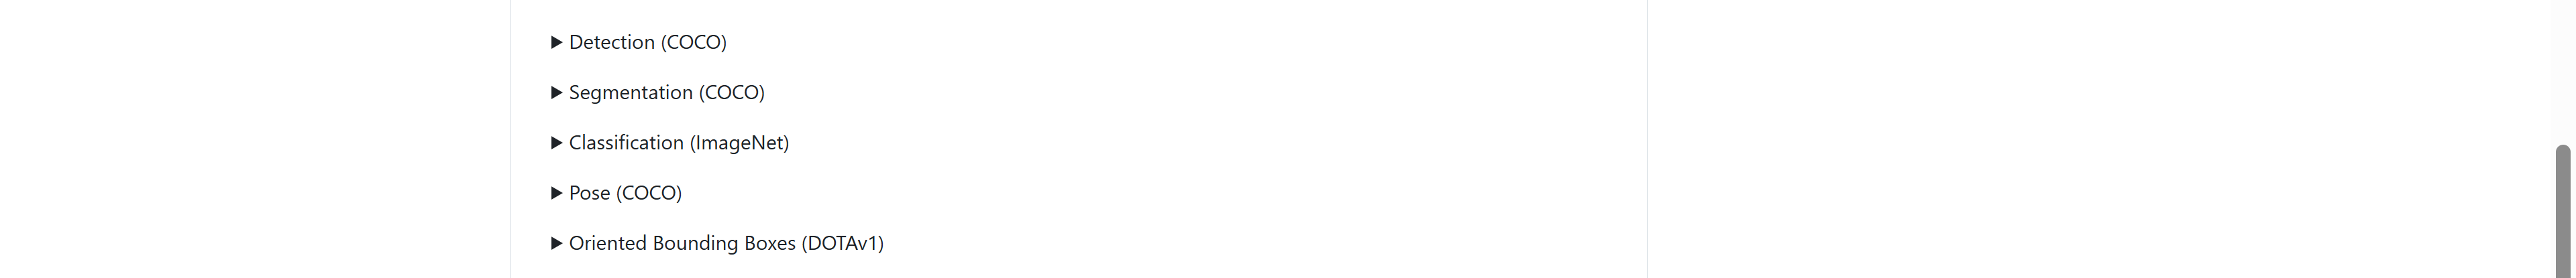

## 3.1. 下载模型

- `https://github.com/ultralytics/assets/releases/download/v8.4.0/yolo26l.pt`
- `https://github.com/ultralytics/assets/releases/download/v8.4.0/yolo26l-seg.pt`

## 3.2. 模型推理

- 条件：
    - 环境
    - 模型下载好
    - 图片
- 重点：
    - 理解推理后返回的数据。

In [ ]:
# 1. 引用模块
from ultralytics import YOLO

# ?YOLO   # 摘要帮助
# help(YOLO)   # 详细帮助
# dir(YOLO)  # 查看成员
# 2. 加载模型
dect = YOLO("E:/models/yolo26m.pt")

dect=dect.cpu()
# dect=dect.xpu()   # 安装xpu版本的torch，torchvision torchaudio

# 3. 推理(dect对象是可调用对象__call__==forward)
objs = dect(["../../assets/images/04_traffic.jpg","../../assets/images/05_landscape.jpg"])  # 把对象当成函数使用



In [ ]:
#测试

objs_new = YOLO("E:/models/yolo26m.pt")(["../../assets/images/04_traffic.jpg","../../assets/images/05_landscape.jpg"])
objs_new

In [15]:
# 4. 解析推理的结果数据
boxes = objs[0].boxes
boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 25.,  0.,  0.,  3., 25.,  0., 26.,  1., 26.,  0.,  3., 25.])
conf: tensor([0.9174, 0.8940, 0.8889, 0.8848, 0.8702, 0.8577, 0.8404, 0.8379, 0.7934, 0.7591, 0.5733, 0.5659, 0.5348, 0.5294, 0.4195, 0.2938, 0.2894, 0.2645, 0.2539, 0.2509])
data: tensor([[1.0103e+03, 2.6805e+02, 1.0849e+03, 4.1385e+02, 9.1740e-01, 0.0000e+00],
        [5.1694e+02, 6.1402e+02, 6.1312e+02, 8.0718e+02, 8.9395e-01, 0.0000e+00],
        [8.9670e+02, 3.6901e+02, 9.7744e+02, 5.3189e+02, 8.8895e-01, 0.0000e+00],
        [9.6858e+02, 3.7115e+02, 1.0510e+03, 5.3796e+02, 8.8479e-01, 0.0000e+00],
        [6.4271e+02, 3.7177e+02, 7.1570e+02, 5.3279e+02, 8.7020e-01, 0.0000e+00],
        [2.2036e+02, 3.5799e+02, 2.7834e+02, 4.8512e+02, 8.5772e-01, 0.0000e+00],
        [1.7657e+02, 3.0414e+02, 2.3713e+02, 4.6534e+02, 8.4036e-01, 0.0000e+00],
        [5.8298e+02, 2.4492e+02, 6.6222e+02, 3.8740e+02, 8.3788e-01, 0.00

In [16]:
names = objs[0].names

In [17]:
names

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

In [18]:
cls = boxes.cls

In [19]:
cls

tensor([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 25.,  0.,  0.,  3., 25.,  0., 26.,  1., 26.,  0.,  3., 25.])

In [20]:
cls = cls.detach().cpu().numpy()

In [21]:
cls=cls.astype(int)

In [22]:
cls

array([ 0,  0,  0,  0,  0,  0,  0,  0, 25,  0,  0,  3, 25,  0, 26,  1, 26,  0,  3, 25])

In [23]:
for c in cls:
    print(F"类别id：{c}，类别名：{names[c]}")

类别id：0，类别名：person
类别id：0，类别名：person
类别id：0，类别名：person
类别id：0，类别名：person
类别id：0，类别名：person
类别id：0，类别名：person
类别id：0，类别名：person
类别id：0，类别名：person
类别id：25，类别名：umbrella
类别id：0，类别名：person
类别id：0，类别名：person
类别id：3，类别名：motorcycle
类别id：25，类别名：umbrella
类别id：0，类别名：person
类别id：26，类别名：handbag
类别id：1，类别名：bicycle
类别id：26，类别名：handbag
类别id：0，类别名：person
类别id：3，类别名：motorcycle
类别id：25，类别名：umbrella


In [24]:
# 概率
conf = boxes.conf

In [25]:
conf

tensor([0.9174, 0.8940, 0.8889, 0.8848, 0.8702, 0.8577, 0.8404, 0.8379, 0.7934, 0.7591, 0.5733, 0.5659, 0.5348, 0.5294, 0.4195, 0.2938, 0.2894, 0.2645, 0.2539, 0.2509])

In [26]:
conf = conf.detach().cpu().numpy()

In [27]:
conf

array([     0.9174,     0.89395,     0.88895,     0.88479,      0.8702,     0.85772,     0.84036,     0.83788,     0.79345,     0.75915,     0.57333,     0.56593,     0.53481,     0.52936,     0.41948,     0.29384,     0.28941,     0.26454,     0.25392,      0.2509], dtype=float32)

In [28]:
xyxy = boxes.xyxy
xyxy = xyxy.detach().cpu().numpy()
xyxy = xyxy.astype(int)
xyxy  # 一行一个目标

array([[1010,  268, 1084,  413],
       [ 516,  614,  613,  807],
       [ 896,  369,  977,  531],
       [ 968,  371, 1051,  537],
       [ 642,  371,  715,  532],
       [ 220,  357,  278,  485],
       [ 176,  304,  237,  465],
       [ 582,  244,  662,  387],
       [ 653,  339,  740,  383],
       [  99,  151,  155,  253],
       [ 823,    0,  901,  131],
       [ 949,    0, 1022,  114],
       [  83,   90,  173,  159],
       [ 713,  139,  795,  281],
       [ 103,  193,  120,  221],
       [ 580,  307,  639,  424],
       [ 102,  196,  120,  221],
       [ 672,  282,  739,  445],
       [ 829,   54,  883,  156],
       [  84,  117,  172,  158]])

----


image 1/1 e:\ai_learning\notebooks\01_machine_vision\..\..\assets\images\04_traffic.jpg: 448x640 14 persons, 1 bicycle, 1 motorcycle, 2 umbrellas, 2 handbags, 83.4ms
Speed: 1.9ms preprocess, 83.4ms inference, 3.9ms postprocess per image at shape (1, 3, 448, 640)
(20, 448, 640)
-----------------------
20 448 640


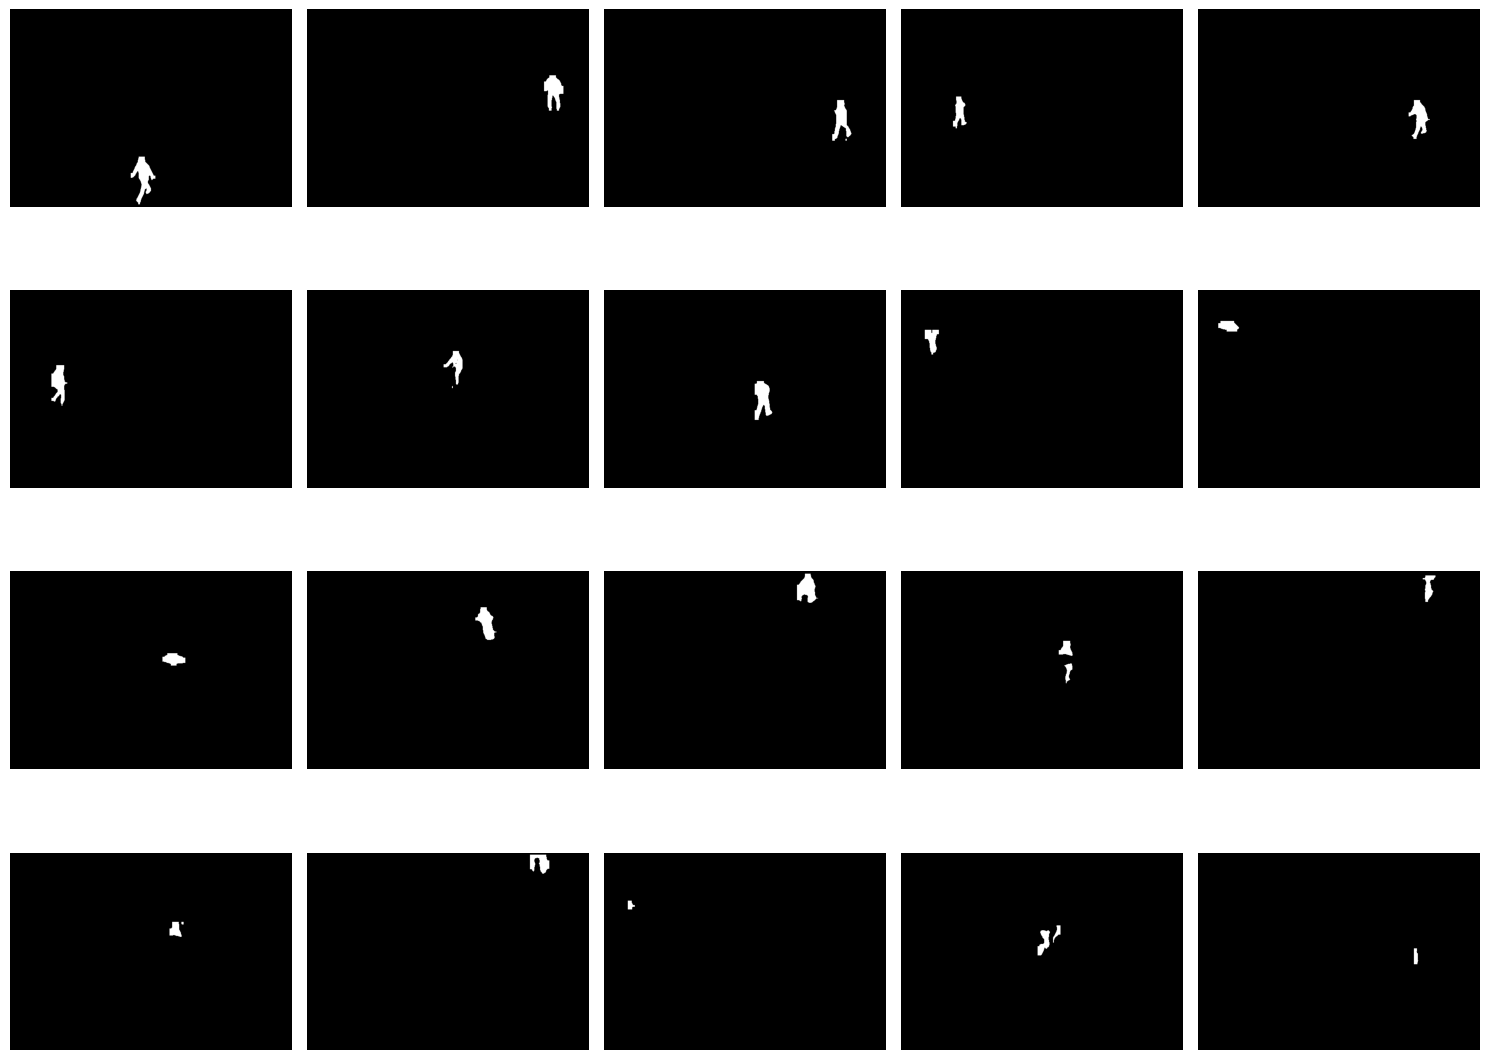

In [41]:
from ultralytics import YOLO
seg = YOLO("E:/models/yolo26l-seg.pt")
seg_objs = seg("../../assets/images/04_traffic.jpg")
#seg_objs

results = seg_objs[0].masks
# results


data = results.data.cpu().numpy()

print(data.shape)  # (num, h, w)

print("-----------------------")
xy = results.xy
data[0, :, :]


#显示
import matplotlib.pyplot as plt

num, h, w = data.shape
print(num, h, w)

plt.figure(figsize=(5*3, 4*3))

for i in range(num):
    plt.subplot(4, 5, i+1)
    plt.imshow(data[i], cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

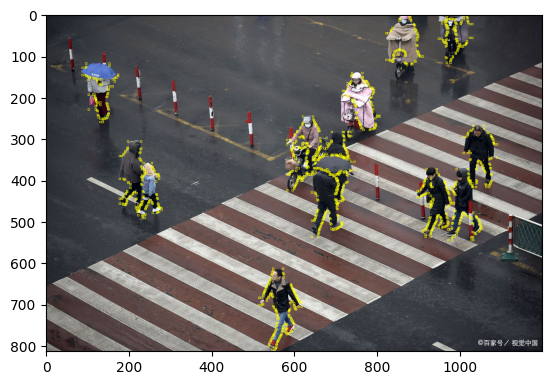

In [ ]:
# 取第目标的轮廓坐标
import cv2
img  = cv2.imread("../../assets/images/04_traffic.jpg", cv2.IMREAD_COLOR_RGB)


for i in range(len(xy)):
    o = xy[i]
    for x, y in o:
        x = int(x)
        y = int(y)
        img = cv2.rectangle(img, rec=(x, y, 5, 5), color=(255, 255, 0), thickness=0)
        plt.imshow(img)



plt.show()

20


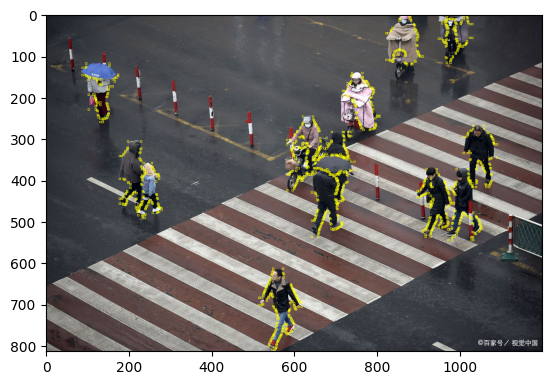

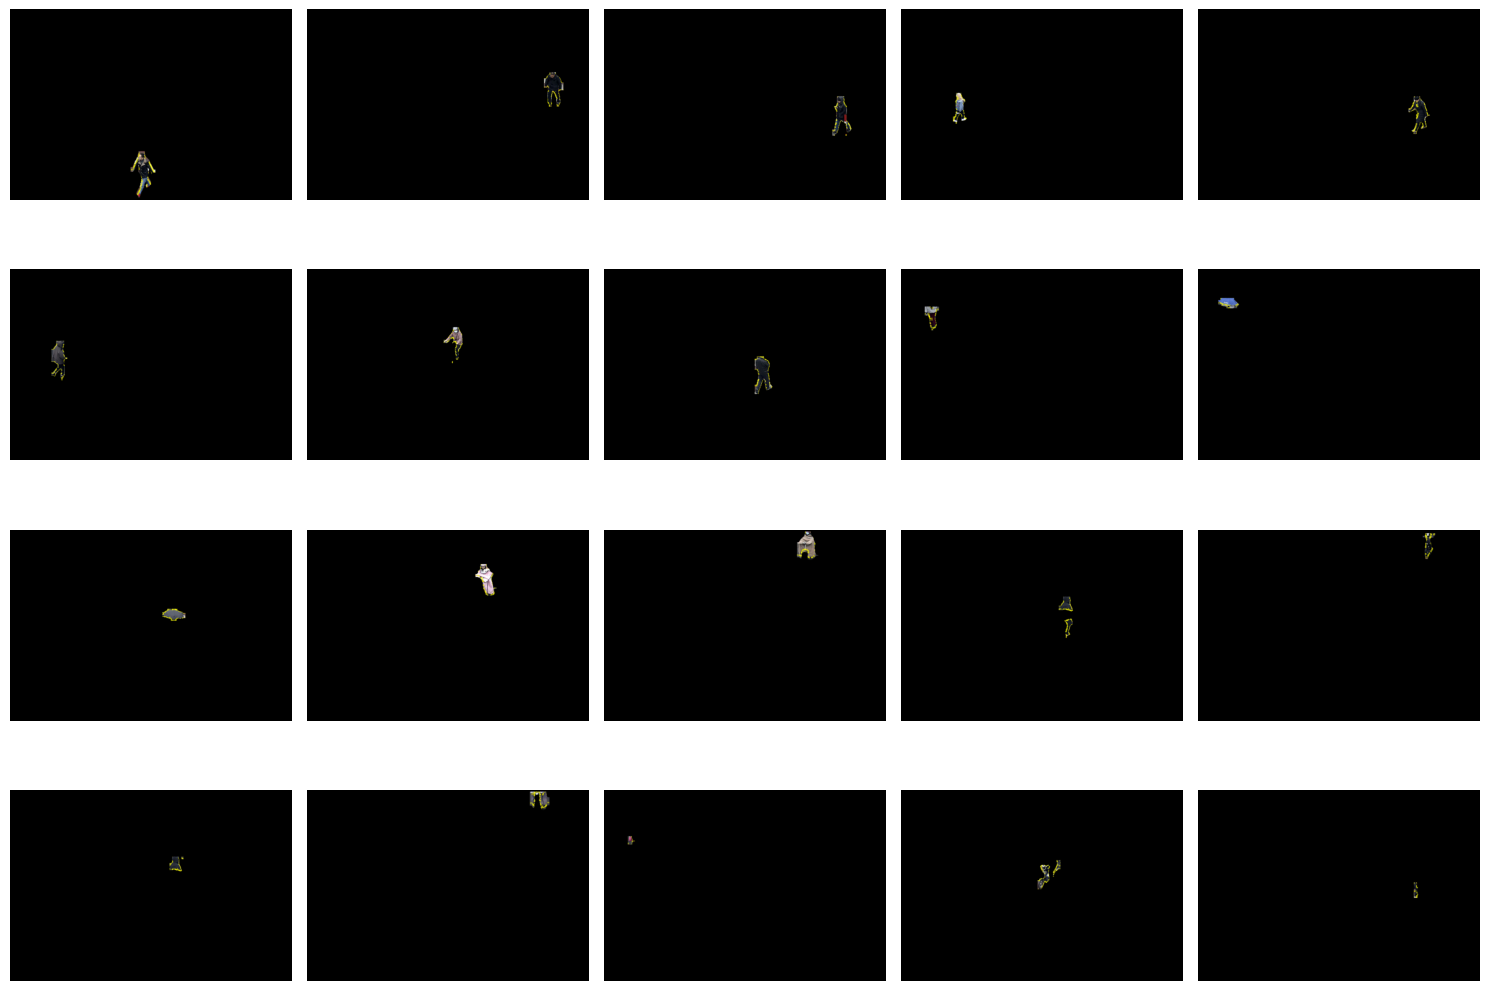

In [ ]:
# 把目标从原图挖出来

# 1. 把黑白图转为三通道彩色图（叠加的原理）：numpy.stack  (torch.stack, torch.cat)
bw_obj = data[1, :, :] * 255
import numpy as np

print(data.shape[0])

# img_obj = np.stack([bw_obj, bw_obj, bw_obj], axis=2)  # H, W, C
# plt.imshow(img_obj)

# print(img.shape)
# print(img_obj.shape)

# # 对图像进行简单缩放
# h, w, _ = img.shape
# img_obj = cv2.resize(img_obj, (w, h))
# #2. 运算

# img_new = img & img_obj
# plt.imshow(img_new)

plt.imshow(img)
h, w, _ = img.shape
plt.figure(figsize=(5*3, 4*3))
for i in range(data.shape[0]):
    bw_obj = data[i, :, :] * 255
    img_obj = np.stack([bw_obj, bw_obj, bw_obj], axis=2)  # H, W, C
    img_obj = cv2.resize(img_obj, (w, h))
    img_new = img & img_obj
    plt.subplot(4, 5, i+1)
    plt.axis("off")
    plt.imshow(img_new)
    plt.tight_layout()
plt.show()




------

## 3.3. 推理数据的处理-图像运算


0: 448x640 14 persons, 1 bicycle, 1 motorcycle, 2 umbrellas, 2 handbags, 83.4ms
Speed: 2.6ms preprocess, 83.4ms inference, 3.6ms postprocess per image at shape (1, 3, 448, 640)


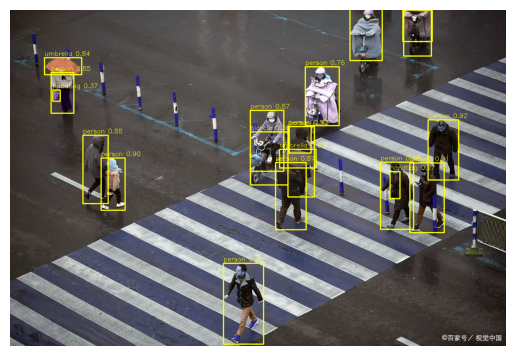

In [72]:
def detect_objects_by_yolo(img, model_file="E:/models/yolo26l-seg.pt"):
    # from ultralytics import YOLO
    import ultralytics  # 网络模型
    import numpy        # 图像运算
    import cv2          # 图像处理
    import torch        # 暂时不直接使用
    
    model_seg = ultralytics.YOLO(model_file)
    # 选择使用gpu还是cpu
    model_seg = model_seg.cuda()  # 使用gpu
    # model_seg.cpu()   # 使用cpu
    results = model_seg(img)[0]   # 基本上都支持（方便）

    boxes = results.boxes  # 侦测的目标
    masks = results.masks  # 分隔
    names = results.names  # 用来把id转换为名字
    
    # 名字
    # boxes.cls
    obj_names = [names[int(c)] for c in boxes.cls.cpu().numpy()]   # 生成表达式（逐次生成：效率高）
    # 概率
    obj_confs = boxes.conf.cpu().numpy()   # .tolist()  # numpy数组，python数组
    # 边框
    obj_boxes = boxes.xyxy.cpu().numpy().astype(int)
    # # 分隔目标
    obj_masks = masks.data.cpu().numpy() * 255 

    h, w , _ = img.shape

    if masks is not None:
        obj_masks = masks.data.cpu().numpy() * 255   # shape: (N, H_mask, W_mask)
        # 逐个掩膜缩放
        resized_masks = []
        for mask in obj_masks:
            resized = cv2.resize(mask, (w, h))
            resized_masks.append(resized)
        obj_masks = np.stack(resized_masks, axis=0)   # shape: (N, H, W)
    else:
        obj_masks = np.array([]) 

    return obj_names, obj_confs, obj_boxes, obj_masks


import cv2

img = cv2.imread("../../assets/images/04_traffic.jpg")

obj_names, obj_confs, obj_boxes, obj_masks = detect_objects_by_yolo(img)

for name, conf, box in zip(obj_names, obj_confs, obj_boxes):
    cv2.rectangle(img, (box[0], box[1]), (box[2], box[3]), color=(255, 255, 0), thickness=2)
    cv2.putText(img, F"{name} {conf:.2f}", (box[0], box[1]-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)
plt.imshow(img)
plt.axis("off")
plt.show()


- 文档注释：（边开发，边撰写API手册）
    - 模块文档注释
    - 类文档注释
    - 函数文档知识

----